# Importing Necessary Libraries

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Data Loading

In [63]:
df = pd.read_csv('/content/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Exploratory Data Analysis (EDA) and Data Preprocessing

In [64]:
df.shape

(891, 12)

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [78]:
df.describe()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
count,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000
mean,448.589888,0.404494,2.240169,0.636236,29.642093,0.514045,0.432584,34.567251
std,258.683191,0.491139,0.836854,0.481420,14.492933,0.930692,0.854181,52.938648
min,1.000000,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000
25%,222.750000,0.000000,1.000000,0.000000,20.000000,0.000000,0.000000,8.050000
50%,445.000000,0.000000,2.000000,1.000000,28.000000,0.000000,0.000000,15.645850
75%,677.250000,1.000000,3.000000,1.000000,38.000000,1.000000,1.000000,33.000000
max,891.000000,1.000000,3.000000,1.000000,80.000000,5.000000,6.000000,512.329200


In [66]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [67]:
df.dropna(subset = ['Age', 'Embarked'], inplace = True)

In [68]:
df.drop('Cabin', axis = 1, inplace = True)

In [69]:
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

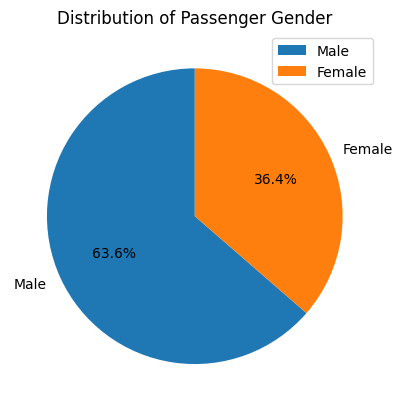

In [70]:
plt.title('Distribution of Passenger Gender')
plt.pie(df['Sex'].value_counts(), labels = ['Male','Female'], autopct = '%1.1f%%', startangle = 90)
plt.legend()
plt.show()

The distribution of passengers by gender reveals that approximately 63.6% were male and 36.4% were female, indicating a higher proportion of male passengers on the cruise.

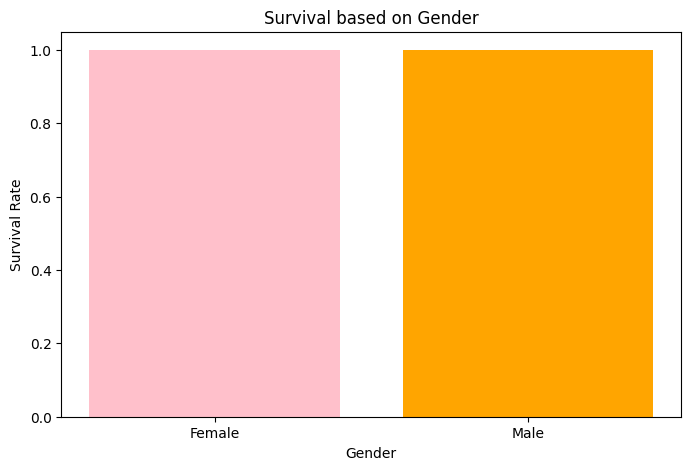

In [71]:
plt.figure(figsize = (8, 5))
plt.title("Survival based on Gender")
plt.bar(df['Sex'].replace({0: 'Male', 1: 'Female'}), df['Survived'], color = ('pink', 'orange'))
plt.xlabel('Gender')
plt.ylabel('Survival Rate')
plt.show()

The visualization suggests that the survival rates of males and females are similar. This observation warrants further investigation as it may indicate inconsistencies or potential biases in the data

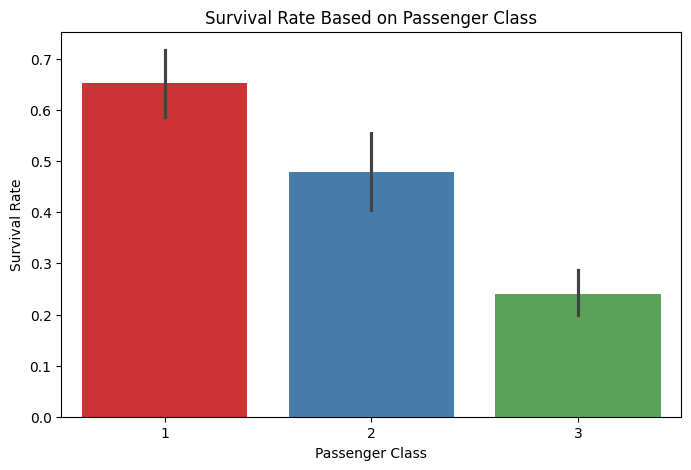

In [72]:
plt.figure(figsize = (8, 5))
plt.title("Survival Rate Based on Passenger Class")
sb.barplot(x='Pclass', y='Survived', data=df, palette="Set1")
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

The bar plot illustrates that passengers traveling in first class had a higher survival rate compared to those in second and third class. Passengers in second class exhibited a moderate survival rate, while those in third class had the lowest survival rate.

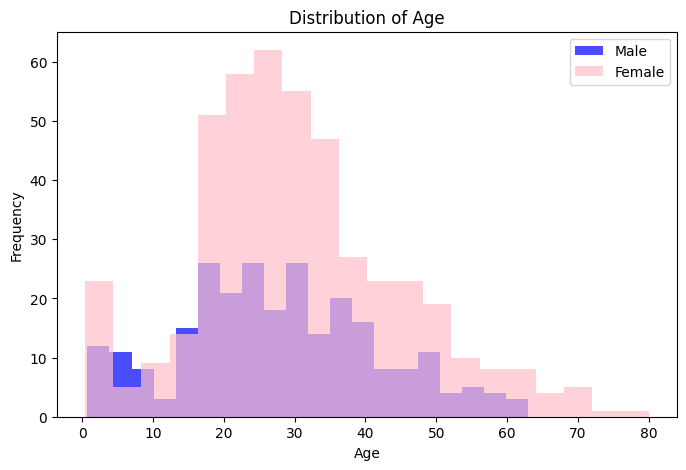

In [73]:
plt.figure(figsize=(8, 5))
plt.title("Distribution of Age")
plt.hist(df[df['Sex'] == 0]['Age'], bins=20, alpha=0.7, label='Male', color='blue')
plt.hist(df[df['Sex'] == 1]['Age'], bins=20, alpha=0.7, label='Female', color='pink')
plt.legend()
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

The histogram illustrates the age distribution of male and female passengers, showing a tendency for males to be slightly younger on average compared to females.

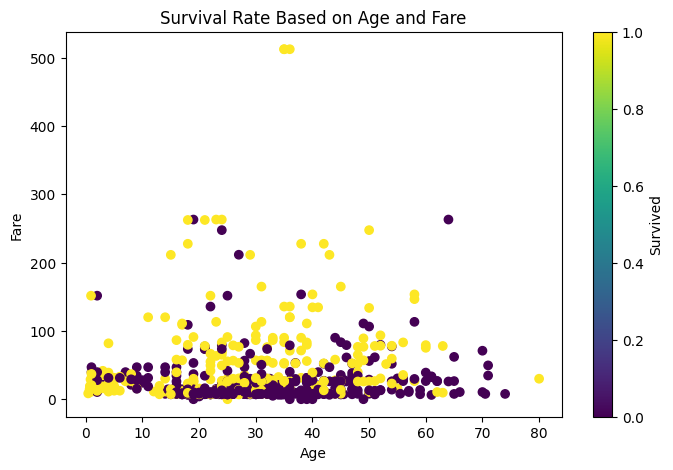

In [81]:
plt.figure(figsize=(8, 5))
plt.title("Survival Rate Based on Age and Fare")
plt.scatter(df['Age'], df['Fare'], c=df['Survived'], cmap='viridis')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.colorbar(label='Survived')
plt.show()

This scatter plot suggests that passengers with lower or moderate age and fare tended to have a higher survival rate

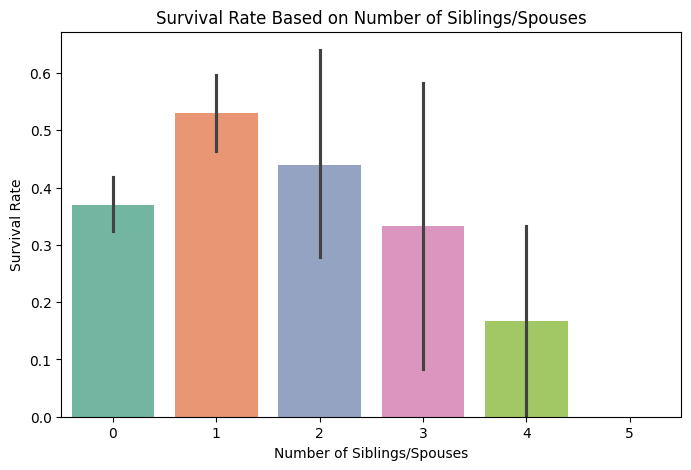

In [75]:
plt.figure(figsize=(8, 5))
plt.title("Survival Rate Based on Number of Siblings/Spouses")
sb.barplot(x='SibSp', y='Survived', data=df, palette="Set2")
plt.xlabel('Number of Siblings/Spouses')
plt.ylabel('Survival Rate')
plt.show()

This graph potrays the Survival rate based on number of siblings/children

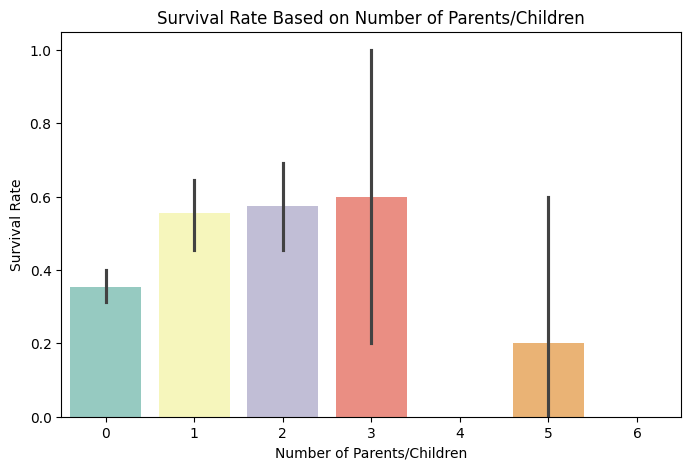

In [76]:
plt.figure(figsize=(8, 5))
plt.title("Survival Rate Based on Number of Parents/Children")
sb.barplot(x='Parch', y='Survived', data=df, palette="Set3")
plt.xlabel('Number of Parents/Children')
plt.ylabel('Survival Rate')
plt.show()

This graph potrays the Survival rate based on number of parents/children

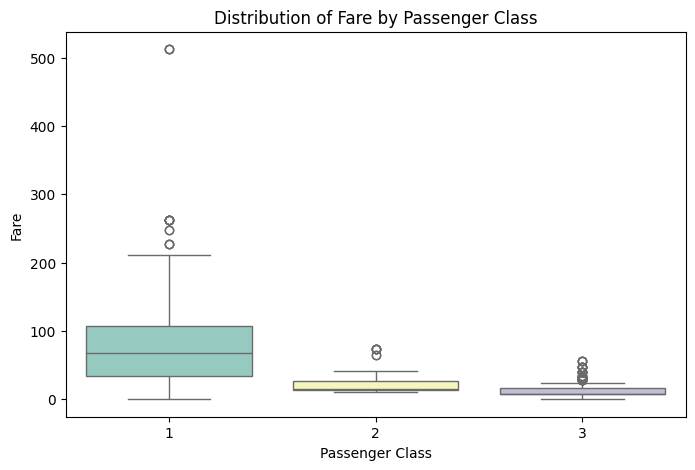

In [77]:
plt.figure(figsize=(8, 5))
plt.title("Distribution of Fare by Passenger Class")
sb.boxplot(x='Pclass', y='Fare', data=df, palette="Set3")
plt.xlabel('Passenger Class')
plt.ylabel('Fare')
plt.show()

This graph shows the box plot distibution for all the passenger classes to detect the outliers in the data